[CHECK 1] Device: cuda
[CHECK 1] GPU name   : NVIDIA GeForce RTX 4060 Ti
[CHECK 1] GPU memory : 16.0 GB

[CHECK 2] Mutual embedding shape : (364997, 64)
[CHECK 2] Salient embedding shape: (364997, 64)
[CHECK 2] IDpol array shape      : (364997,)
[CHECK 2] Year  array shape      : (364997,)
[CHECK 2] Mutual embedding has NaN : False
[CHECK 2] Salient embedding has NaN: False
[CHECK 2] Embedding lookup table size: 364,997

[CHECK 3] Label lookup size: 364,997
[CHECK 3] Overall positive rate: 12.67%

[CHECK 4] Building embedding-based sequences...
[CHECK 4] Train sequences: 49,974
[CHECK 4] Val   sequences: 10,709
[CHECK 4] Test  sequences: 10,709
[CHECK 4] Example — IDpol: PN98494, length: 5, input shape: (5, 128), labels: [0 0 0 0 0]

[CHECK 5] Batch sanity check:
  input shape : torch.Size([64, 9, 128])
  label shape : torch.Size([64, 9])
  mask shape  : torch.Size([64, 9])
  mask example: tensor([ True,  True,  True,  True, False, False, False, False, False])

[CHECK 6] Model created.

C:\Users\miy\miniconda3\envs\env_ts3l\lib\site-packages\torch\nn\modules\transformer.py:508: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\NestedTensorImpl.cpp:182.)
  output = torch._nested_tensor_from_mask(


Epoch  1/10 | train_loss: 0.9951 | val_loss: 1.0031
Epoch  2/10 | train_loss: 0.9897 | val_loss: 1.0176
Epoch  3/10 | train_loss: 0.9877 | val_loss: 1.0014
Epoch  4/10 | train_loss: 0.9875 | val_loss: 1.0048
Epoch  5/10 | train_loss: 0.9863 | val_loss: 1.0038
Epoch  6/10 | train_loss: 0.9866 | val_loss: 1.0028
Epoch  7/10 | train_loss: 0.9863 | val_loss: 1.0026
Epoch  8/10 | train_loss: 0.9860 | val_loss: 1.0149
Epoch  9/10 | train_loss: 0.9869 | val_loss: 1.0018
Epoch 10/10 | train_loss: 0.9852 | val_loss: 1.0091


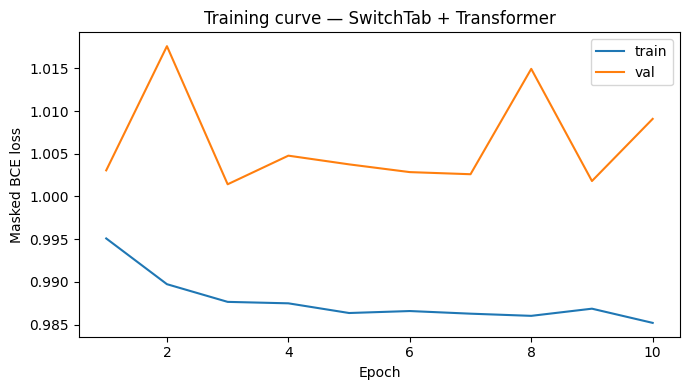

[CHECK 9] Saved: data/results/05_training_curve.png

[CHECK 10] ===== Test Set Evaluation (SwitchTab + Transformer) =====
  Total timestep predictions : 54,755
  Positive rate in test      : 12.79%
  AUC-ROC                    : 0.7680
  F1 @ threshold=0.5         : 0.3561
  Best threshold             : 0.584
  Best F1                    : 0.3790
  Precision @ best thr       : 0.2651
  Recall    @ best thr       : 0.6644

[CHECK 11] Saved: data/results/05_switchtab_transformer.pt
[CHECK 11] Saved: data/results/05_test_predictions.npz

===== Model Comparison =====
Metric                         Raw Transformer (nb03) SwitchTab+Transformer (nb05)
--------------------------------------------------------------------------------
AUC-ROC                                        0.7680                       0.7680  ↓ 0.0000
F1 @ threshold=0.5                             0.3574                       0.3561  ↓ 0.0013
Best F1 (optimal threshold)                    0.3780                       0.37

In [2]:
# ============================================================
# Notebook    : 05_transformer_with_switchtab.ipynb
# Description : Transformer longitudinal risk model using
#               SwitchTab pretrained mutual/salient embeddings
#               as input, replacing raw 5-feature vectors.
#               Results are compared against notebook 03
#               (raw feature Transformer) to validate the
#               core contribution: SwitchTab pretraining
#               improves longitudinal risk prediction.
#
#               Input per timestep (previously: 5 raw features):
#               - mutual  embedding : 64-dim (time-invariant
#                                     individual risk trait)
#               - salient embedding : 64-dim (year-specific
#                                     risk deviation signal)
#               - concatenated      : 128-dim per timestep
# ============================================================


# ============================================================
# 0. Install dependencies (run once)
# ============================================================
# pip install torch scikit-learn matplotlib numpy pandas


# ============================================================
# 1. Common imports
# ============================================================
import os
import pickle
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, f1_score, precision_recall_curve

torch.manual_seed(42)
np.random.seed(42)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[CHECK 1] Device: {DEVICE}")
if torch.cuda.is_available():
    print(f"[CHECK 1] GPU name   : {torch.cuda.get_device_name(0)}")
    print(f"[CHECK 1] GPU memory : {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")

os.makedirs("data/results", exist_ok=True)


# ============================================================
# 2. Load SwitchTab embeddings (from notebook 04)
#    - mutual  : time-invariant individual risk trait (64-dim)
#    - salient : year-specific risk deviation signal  (64-dim)
#    - IDpol, Year: keys for joining back to sequence structure
# ============================================================
emb = np.load("data/switchtab/embeddings.npz", allow_pickle=True)

mutual_emb  = emb["mutual"]   # (364997, 64)
salient_emb = emb["salient"]  # (364997, 64)
idpol_arr   = emb["IDpol"]    # (364997,)
year_arr    = emb["Year"]     # (364997,)

print(f"\n[CHECK 2] Mutual embedding shape : {mutual_emb.shape}")
print(f"[CHECK 2] Salient embedding shape: {salient_emb.shape}")
print(f"[CHECK 2] IDpol array shape      : {idpol_arr.shape}")
print(f"[CHECK 2] Year  array shape      : {year_arr.shape}")
print(f"[CHECK 2] Mutual embedding has NaN : {np.isnan(mutual_emb).any()}")
print(f"[CHECK 2] Salient embedding has NaN: {np.isnan(salient_emb).any()}")

# Build a lookup: (IDpol, Year) -> row index in embedding arrays
emb_index = {(idpol_arr[i], year_arr[i]): i
             for i in range(len(idpol_arr))}
print(f"[CHECK 2] Embedding lookup table size: {len(emb_index):,}")


# ============================================================
# 3. Load label data (from notebook 01)
#    - Need Label per (IDpol, Year) to pair with embeddings
# ============================================================
df = pd.read_csv("data/fremotor_multi_history_features.csv")
label_lookup = {(row["IDpol"], row["Year"]): row["Label"]
                for _, row in df.iterrows()}

print(f"\n[CHECK 3] Label lookup size: {len(label_lookup):,}")
print(f"[CHECK 3] Overall positive rate: "
      f"{sum(label_lookup.values()) / len(label_lookup) * 100:.2f}%")


# ============================================================
# 4. Build longitudinal sequences using SwitchTab embeddings
#    - Each sequence = list of (mutual, salient, label) per year
#    - Sequence order: ascending Year within each IDpol
#    - Each timestep input = concat(mutual, salient) = 128-dim
#    - This replaces the raw 5-feature sequence from notebook 02
# ============================================================
df_sorted = df.sort_values(["IDpol", "Year"]).reset_index(drop=True)

def build_emb_sequences(ids, emb_index, mutual_emb, salient_emb,
                        label_lookup, year_arr, idpol_arr):
    sequences = []
    id_set = set(ids)

    # group IDpol -> list of years
    id_to_years = {}
    for i in range(len(idpol_arr)):
        idpol = idpol_arr[i]
        if idpol in id_set:
            if idpol not in id_to_years:
                id_to_years[idpol] = []
            id_to_years[idpol].append(year_arr[i])

    for idpol in ids:
        if idpol not in id_to_years:
            continue
        years = sorted(id_to_years[idpol])
        mutual_seq, salient_seq, label_seq = [], [], []
        for yr in years:
            key = (idpol, yr)
            if key not in emb_index:
                continue
            idx = emb_index[key]
            mutual_seq.append(mutual_emb[idx])
            salient_seq.append(salient_emb[idx])
            label_seq.append(label_lookup.get(key, 0))

        if len(mutual_seq) < 2:   # skip single-timestep sequences
            continue

        sequences.append({
            "IDpol"  : idpol,
            "length" : len(mutual_seq),
            # concat mutual + salient -> 128-dim per timestep
            "input"  : np.concatenate(
                [np.array(mutual_seq), np.array(salient_seq)], axis=1
            ).astype(np.float32),
            "label"  : np.array(label_seq, dtype=np.int64),
        })
    return sequences


# Load IDpol splits from notebook 02
with open("data/sequences/train_sequences.pkl", "rb") as f:
    train_seqs_raw = pickle.load(f)
with open("data/sequences/val_sequences.pkl", "rb") as f:
    val_seqs_raw = pickle.load(f)
with open("data/sequences/test_sequences.pkl", "rb") as f:
    test_seqs_raw = pickle.load(f)

train_ids = [s["IDpol"] for s in train_seqs_raw]
val_ids   = [s["IDpol"] for s in val_seqs_raw]
test_ids  = [s["IDpol"] for s in test_seqs_raw]

print(f"\n[CHECK 4] Building embedding-based sequences...")
train_seqs = build_emb_sequences(train_ids, emb_index, mutual_emb,
                                  salient_emb, label_lookup,
                                  year_arr, idpol_arr)
val_seqs   = build_emb_sequences(val_ids,   emb_index, mutual_emb,
                                  salient_emb, label_lookup,
                                  year_arr, idpol_arr)
test_seqs  = build_emb_sequences(test_ids,  emb_index, mutual_emb,
                                  salient_emb, label_lookup,
                                  year_arr, idpol_arr)

print(f"[CHECK 4] Train sequences: {len(train_seqs):,}")
print(f"[CHECK 4] Val   sequences: {len(val_seqs):,}")
print(f"[CHECK 4] Test  sequences: {len(test_seqs):,}")
print(f"[CHECK 4] Example — IDpol: {train_seqs[0]['IDpol']}, "
      f"length: {train_seqs[0]['length']}, "
      f"input shape: {train_seqs[0]['input'].shape}, "
      f"labels: {train_seqs[0]['label']}")


# ============================================================
# 5. Dataset and collate function
#    - Identical padding/masking logic as notebook 03
#    - Input dim is now 128 (64 mutual + 64 salient) instead
#      of 5 raw features — this is the only structural change
# ============================================================
class SequenceDataset(Dataset):
    def __init__(self, sequences):
        self.sequences = sequences
    def __len__(self):
        return len(self.sequences)
    def __getitem__(self, idx):
        return self.sequences[idx]

def collate_fn(batch):
    max_len    = max(item["length"] for item in batch)
    batch_size = len(batch)
    input_dim  = batch[0]["input"].shape[1]   # 128

    input_padded   = torch.zeros(batch_size, max_len, input_dim, dtype=torch.float32)
    label_padded   = torch.zeros(batch_size, max_len, dtype=torch.float32)
    attention_mask = torch.zeros(batch_size, max_len, dtype=torch.bool)

    for i, item in enumerate(batch):
        L = item["length"]
        input_padded[i, :L]   = torch.tensor(item["input"])
        label_padded[i, :L]   = torch.tensor(item["label"], dtype=torch.float32)
        attention_mask[i, :L] = True

    return {
        "input" : input_padded,
        "label" : label_padded,
        "mask"  : attention_mask,
        "IDpol" : [item["IDpol"] for item in batch],
    }

BATCH_SIZE = 64   # larger input dim (128) so slightly smaller batch than nb03

train_loader = DataLoader(SequenceDataset(train_seqs), batch_size=BATCH_SIZE,
                          shuffle=True,  collate_fn=collate_fn)
val_loader   = DataLoader(SequenceDataset(val_seqs),   batch_size=BATCH_SIZE,
                          shuffle=False, collate_fn=collate_fn)
test_loader  = DataLoader(SequenceDataset(test_seqs),  batch_size=BATCH_SIZE,
                          shuffle=False, collate_fn=collate_fn)

# Sanity check one batch
sample = next(iter(train_loader))
print(f"\n[CHECK 5] Batch sanity check:")
print(f"  input shape : {sample['input'].shape}")
print(f"  label shape : {sample['label'].shape}")
print(f"  mask shape  : {sample['mask'].shape}")
print(f"  mask example: {sample['mask'][0]}")


# ============================================================
# 6. Model definition — Transformer Encoder + per-timestep head
#    - Input: 128-dim (mutual 64 + salient 64) per timestep
#    - Architecture mirrors notebook 03 for fair comparison,
#      with input_dim changed from 5 to 128
#    - YearGap is now encoded inside salient, so no separate
#      positional encoding needed (same reasoning as nb03)
# ============================================================
class SwitchTabTransformer(nn.Module):
    def __init__(self, input_dim=128, emb_dim=64, n_heads=4,
                 n_layers=2, ff_dim=128, dropout=0.1):
        super().__init__()

        # project 128-dim switchtab input into transformer emb space
        self.input_proj = nn.Sequential(
            nn.Linear(input_dim, emb_dim),
            nn.LayerNorm(emb_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
        )

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=emb_dim,
            nhead=n_heads,
            dim_feedforward=ff_dim,
            dropout=dropout,
            batch_first=True,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)

        # per-timestep classification head
        self.classifier = nn.Sequential(
            nn.Linear(emb_dim, emb_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(emb_dim // 2, 1),
        )

    def forward(self, x, attention_mask):
        # x: [B, T, 128]  attention_mask: [B, T] True=real
        x = self.input_proj(x)                    # [B, T, emb_dim]
        src_key_padding_mask = ~attention_mask     # invert: True=ignore
        encoded = self.encoder(
            x, src_key_padding_mask=src_key_padding_mask
        )                                          # [B, T, emb_dim]
        logits = self.classifier(encoded).squeeze(-1)  # [B, T]
        return logits


model = SwitchTabTransformer(input_dim=128).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(f"\n[CHECK 6] Model created. Total parameters: {n_params:,}")
print(f"[CHECK 6] Input dim: 128 (64 mutual + 64 salient from SwitchTab)")

# quick forward pass check
with torch.no_grad():
    test_out = model(
        sample["input"].to(DEVICE),
        sample["mask"].to(DEVICE)
    )
print(f"[CHECK 6] Forward pass output shape: {test_out.shape} (should be [batch, max_len])")


# ============================================================
# 7. Loss function — masked BCE with pos_weight
#    - Same design as notebook 03 for fair comparison
#    - pos_weight based on 12.67% positive rate from notebook 01
# ============================================================
POS_WEIGHT = torch.tensor((1 - 0.1267) / 0.1267).to(DEVICE)
print(f"\n[CHECK 7] pos_weight: {POS_WEIGHT.item():.2f}")

criterion = nn.BCEWithLogitsLoss(pos_weight=POS_WEIGHT, reduction="none")

def masked_bce_loss(logits, labels, mask):
    loss = criterion(logits, labels)
    loss = loss * mask.float()
    return loss.sum() / mask.float().sum()


# ============================================================
# 8. Training loop
# ============================================================
optimizer  = torch.optim.Adam(model.parameters(), lr=1e-3)
N_EPOCHS   = 10

train_losses, val_losses = [], []

print(f"\n[CHECK 8] Starting training ({N_EPOCHS} epochs)...")

for epoch in range(1, N_EPOCHS + 1):
    model.train()
    epoch_train_loss, n_batches = 0.0, 0

    for batch in train_loader:
        inp   = batch["input"].to(DEVICE)
        label = batch["label"].to(DEVICE)
        mask  = batch["mask"].to(DEVICE)

        optimizer.zero_grad()
        logits = model(inp, mask)
        loss   = masked_bce_loss(logits, label, mask)
        loss.backward()
        optimizer.step()

        epoch_train_loss += loss.item()
        n_batches += 1

    avg_train = epoch_train_loss / n_batches
    train_losses.append(avg_train)

    model.eval()
    epoch_val_loss, n_val = 0.0, 0
    with torch.no_grad():
        for batch in val_loader:
            inp   = batch["input"].to(DEVICE)
            label = batch["label"].to(DEVICE)
            mask  = batch["mask"].to(DEVICE)
            logits = model(inp, mask)
            loss   = masked_bce_loss(logits, label, mask)
            epoch_val_loss += loss.item()
            n_val += 1

    avg_val = epoch_val_loss / n_val
    val_losses.append(avg_val)

    print(f"Epoch {epoch:2d}/{N_EPOCHS} | "
          f"train_loss: {avg_train:.4f} | val_loss: {avg_val:.4f}")


# ============================================================
# 9. Training curve
# ============================================================
plt.figure(figsize=(7, 4))
plt.plot(range(1, N_EPOCHS + 1), train_losses, label="train")
plt.plot(range(1, N_EPOCHS + 1), val_losses,   label="val")
plt.xlabel("Epoch")
plt.ylabel("Masked BCE loss")
plt.title("Training curve — SwitchTab + Transformer")
plt.legend()
plt.tight_layout()
plt.savefig("data/results/05_training_curve.png")
plt.show()
print(f"[CHECK 9] Saved: data/results/05_training_curve.png")


# ============================================================
# 10. Evaluation on test set
# ============================================================
model.eval()
all_logits, all_labels = [], []

with torch.no_grad():
    for batch in test_loader:
        inp   = batch["input"].to(DEVICE)
        label = batch["label"].to(DEVICE)
        mask  = batch["mask"].to(DEVICE)

        logits = model(inp, mask)

        flat_logits = logits[mask]
        flat_labels = label[mask]

        all_logits.append(flat_logits.cpu().numpy())
        all_labels.append(flat_labels.cpu().numpy())

all_logits = np.concatenate(all_logits)
all_labels = np.concatenate(all_labels)
all_probs  = 1 / (1 + np.exp(-all_logits))

auc = roc_auc_score(all_labels, all_probs)

# optimal threshold via PR curve
precisions, recalls, thresholds = precision_recall_curve(all_labels, all_probs)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
best_idx   = np.argmax(f1_scores[:-1])
best_thr   = thresholds[best_idx]
f1_best    = f1_scores[best_idx]
f1_05      = f1_score(all_labels, (all_probs >= 0.5).astype(int))

print(f"\n[CHECK 10] ===== Test Set Evaluation (SwitchTab + Transformer) =====")
print(f"  Total timestep predictions : {len(all_labels):,}")
print(f"  Positive rate in test      : {all_labels.mean()*100:.2f}%")
print(f"  AUC-ROC                    : {auc:.4f}")
print(f"  F1 @ threshold=0.5         : {f1_05:.4f}")
print(f"  Best threshold             : {best_thr:.3f}")
print(f"  Best F1                    : {f1_best:.4f}")
print(f"  Precision @ best thr       : {precisions[best_idx]:.4f}")
print(f"  Recall    @ best thr       : {recalls[best_idx]:.4f}")


# ============================================================
# 11. Save model and predictions
# ============================================================
torch.save(model.state_dict(), "data/results/05_switchtab_transformer.pt")
np.savez(
    "data/results/05_test_predictions.npz",
    logits=all_logits,
    labels=all_labels,
    probs=all_probs,
)
print(f"\n[CHECK 11] Saved: data/results/05_switchtab_transformer.pt")
print(f"[CHECK 11] Saved: data/results/05_test_predictions.npz")


# ============================================================
# 12. Comparison table — notebook 03 (raw) vs notebook 05 (SwitchTab)
#     NOTE: notebook 03 results are hardcoded from its output.
#     Update these if you re-run notebook 03.
# ============================================================
NB03_AUC    = 0.7680
NB03_F1_05  = 0.3574
NB03_F1_OPT = 0.3780

print(f"\n===== Model Comparison =====")
print(f"{'Metric':<30} {'Raw Transformer (nb03)':>22} {'SwitchTab+Transformer (nb05)':>28}")
print(f"{'-'*80}")
print(f"{'AUC-ROC':<30} {NB03_AUC:>22.4f} {auc:>28.4f}  "
      f"{'↑' if auc > NB03_AUC else '↓'} {abs(auc - NB03_AUC):.4f}")
print(f"{'F1 @ threshold=0.5':<30} {NB03_F1_05:>22.4f} {f1_05:>28.4f}  "
      f"{'↑' if f1_05 > NB03_F1_05 else '↓'} {abs(f1_05 - NB03_F1_05):.4f}")
print(f"{'Best F1 (optimal threshold)':<30} {NB03_F1_OPT:>22.4f} {f1_best:>28.4f}  "
      f"{'↑' if f1_best > NB03_F1_OPT else '↓'} {abs(f1_best - NB03_F1_OPT):.4f}")
print(f"{'Input representation':<30} {'5 raw features':>22} {'128-dim SwitchTab emb':>28}")
print(f"{'Pairing used in pretraining':<30} {'N/A':>22} {'same-IDpol (t,t+1)':>28}")
print(f"{'='*80}")


# ============================================================
# 13. Summary
# ============================================================
print(f"\n===== Notebook 05 Summary =====")
print(f"SwitchTab embedding dim : 64 mutual + 64 salient = 128 per timestep")
print(f"Transformer input dim   : 128 (vs 5 in notebook 03)")
print(f"Test AUC-ROC            : {auc:.4f} (nb03: {NB03_AUC:.4f})")
print(f"Test Best F1            : {f1_best:.4f} (nb03: {NB03_F1_OPT:.4f})")
delta = auc - NB03_AUC
if delta > 0:
    print(f"Result: SwitchTab pretraining IMPROVED AUC by {delta:.4f} ✅")
else:
    print(f"Result: AUC changed by {delta:.4f} — see Section 12 comparison for analysis.")
print(f"================================")